# **EDA**

## Install Library

In [1]:
!pip install wordcloud matplotlib scikit-learn


[notice] A new release of pip available: 22.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import Library

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import nltk
import ast
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ISNITA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Load Dataset

In [3]:
file_path = 'dataset4.xlsx'
df = pd.read_excel(file_path)

df

,Title,Date,Content,Category,URL
0,"Prabowo: Kalau Ada Kader Gerindra Brengsek, Sa...","Senin, 02 Feb 2026 14:04 WIB",Presiden Prabowo Subianto menegaskan tidak aka...,Politik,https://www.cnnindonesia.com/nasional/20260202...
1,Sjafrie Beber Prabowo Bertemu Tokoh yang Klaim...,"Minggu, 01 Feb 2026 14:00 WIB",Menteri Pertahanan Sjafrie Sjamsoeddin mengung...,Politik,https://www.cnnindonesia.com/nasional/20260201...
2,Menhan Sjafrie Sebut Prabowo Bertemu Tokoh Opo...,"Sabtu, 31 Jan 2026 15:25 WIB","Menteri Pertahanan (Menhan), Sjafrie Sjamsoedd...",Politik,https://www.cnnindonesia.com/nasional/20260131...
3,Komisi XI DPR Segera Bahas Kursi Kosong Bos-Pe...,"Sabtu, 31 Jan 2026 14:20 WIB",Komisi XI DPR disebut akan segera membahas kur...,Politik,https://www.cnnindonesia.com/nasional/20260131...
4,Jokowi Beri Arahan di Penutupan Rakernas PSI H...,"Sabtu, 31 Jan 2026 09:53 WIB",Presiden ke-7 RI Joko Widodo dijadwalkan akan ...,Politik,https://www.cnnindonesia.com/nasional/20260131...
...,...,...,...,...,...
1195,Jurus Cagub Dharma Atasi Banjir: Teknologi Bel...,"Selasa, 12 Nov 2024 14:15 WIB",Calon Gubernur Jakarta Dharma Pongrekun mengun...,Pemilu,https://www.cnnindonesia.com/nasional/20241112...
1196,Komisioner Bawaslu Jember Tolak Disumpah Netra...,"Selasa, 12 Nov 2024 10:48 WIB",Komisioner Bawaslu Jember menolak bersumpah un...,Pemilu,https://www.cnnindonesia.com/nasional/20241112...
1197,"Atasi Kesehatan Mental, Acep-Gita Janji Bangun...","Selasa, 12 Nov 2024 05:01 WIB","Calon Wakil Gubernur Jawa Barat nomor urut 1, ...",Pemilu,https://www.cnnindonesia.com/nasional/20241112...
1198,Erwan Pamer Pencapaian Basmi Stunting di Sumed...,"Senin, 11 Nov 2024 22:35 WIB","Calon Wakil Gubernur Jawa Barat nomor urut 4, ...",Pemilu,https://www.cnnindonesia.com/nasional/20241111...


# **PREPROCESSING**

## Cleaning Data

In [4]:
def cleaning(teks: str) -> str:
    teks = re.sub(r'http\S+|www\.\S+', ' ', teks)
    teks = re.sub(r'[^a-zA-Z\s]', ' ', teks)
    teks = re.sub(r'\s+', ' ', teks).strip()
    return teks

df['Cleaning'] = df['Content'].apply(cleaning)
print("=== Data Asli vs Setelah Cleaning ===")
display(df[['Content', 'Cleaning']])

=== Data Asli vs Setelah Cleaning ===


,Content,Cleaning
0,Presiden Prabowo Subianto menegaskan tidak aka...,Presiden Prabowo Subianto menegaskan tidak aka...
1,Menteri Pertahanan Sjafrie Sjamsoeddin mengung...,Menteri Pertahanan Sjafrie Sjamsoeddin mengung...
2,"Menteri Pertahanan (Menhan), Sjafrie Sjamsoedd...",Menteri Pertahanan Menhan Sjafrie Sjamsoeddin ...
3,Komisi XI DPR disebut akan segera membahas kur...,Komisi XI DPR disebut akan segera membahas kur...
4,Presiden ke-7 RI Joko Widodo dijadwalkan akan ...,Presiden ke RI Joko Widodo dijadwalkan akan me...
...,...,...
1195,Calon Gubernur Jakarta Dharma Pongrekun mengun...,Calon Gubernur Jakarta Dharma Pongrekun mengun...
1196,Komisioner Bawaslu Jember menolak bersumpah un...,Komisioner Bawaslu Jember menolak bersumpah un...
1197,"Calon Wakil Gubernur Jawa Barat nomor urut 1, ...",Calon Wakil Gubernur Jawa Barat nomor urut Git...
1198,"Calon Wakil Gubernur Jawa Barat nomor urut 4, ...",Calon Wakil Gubernur Jawa Barat nomor urut Erw...


## Case Folding

In [5]:
def case_folding(teks: str) -> str:
    return teks.lower()

df['Case Folding'] = df['Cleaning'].apply(case_folding)
print("=== Setelah Cleaning vs Setelah Case Folding ===")
display(df[['Cleaning', 'Case Folding']])

=== Setelah Cleaning vs Setelah Case Folding ===


,Cleaning,Case Folding
0,Presiden Prabowo Subianto menegaskan tidak aka...,presiden prabowo subianto menegaskan tidak aka...
1,Menteri Pertahanan Sjafrie Sjamsoeddin mengung...,menteri pertahanan sjafrie sjamsoeddin mengung...
2,Menteri Pertahanan Menhan Sjafrie Sjamsoeddin ...,menteri pertahanan menhan sjafrie sjamsoeddin ...
3,Komisi XI DPR disebut akan segera membahas kur...,komisi xi dpr disebut akan segera membahas kur...
4,Presiden ke RI Joko Widodo dijadwalkan akan me...,presiden ke ri joko widodo dijadwalkan akan me...
...,...,...
1195,Calon Gubernur Jakarta Dharma Pongrekun mengun...,calon gubernur jakarta dharma pongrekun mengun...
1196,Komisioner Bawaslu Jember menolak bersumpah un...,komisioner bawaslu jember menolak bersumpah un...
1197,Calon Wakil Gubernur Jawa Barat nomor urut Git...,calon wakil gubernur jawa barat nomor urut git...
1198,Calon Wakil Gubernur Jawa Barat nomor urut Erw...,calon wakil gubernur jawa barat nomor urut erw...


## Tokenization

In [6]:
def tokenization(teks: str):
    return teks.split()

df['Tokenization'] = df['Case Folding'].apply(tokenization)
print("=== Setelah Case Folding vs Setelah Tokenization ===")
display(df[['Case Folding', 'Tokenization']])

=== Setelah Case Folding vs Setelah Tokenization ===


,Case Folding,Tokenization
0,presiden prabowo subianto menegaskan tidak aka...,"[presiden, prabowo, subianto, menegaskan, tida..."
1,menteri pertahanan sjafrie sjamsoeddin mengung...,"[menteri, pertahanan, sjafrie, sjamsoeddin, me..."
2,menteri pertahanan menhan sjafrie sjamsoeddin ...,"[menteri, pertahanan, menhan, sjafrie, sjamsoe..."
3,komisi xi dpr disebut akan segera membahas kur...,"[komisi, xi, dpr, disebut, akan, segera, memba..."
4,presiden ke ri joko widodo dijadwalkan akan me...,"[presiden, ke, ri, joko, widodo, dijadwalkan, ..."
...,...,...
1195,calon gubernur jakarta dharma pongrekun mengun...,"[calon, gubernur, jakarta, dharma, pongrekun, ..."
1196,komisioner bawaslu jember menolak bersumpah un...,"[komisioner, bawaslu, jember, menolak, bersump..."
1197,calon wakil gubernur jawa barat nomor urut git...,"[calon, wakil, gubernur, jawa, barat, nomor, u..."
1198,calon wakil gubernur jawa barat nomor urut erw...,"[calon, wakil, gubernur, jawa, barat, nomor, u..."


## Stopword Removal

In [7]:
stopwords_indo = stopwords.words('indonesian')
def stopword_removal(kata: list):
    return [word for word in kata if word not in stopwords_indo]

df['Stopword Removal'] = df['Tokenization'].apply(stopword_removal)
print("=== Setelah Tokenization vs Setelah Stopword Removal ===")
display(df[['Tokenization', 'Stopword Removal']])

=== Setelah Tokenization vs Setelah Stopword Removal ===


,Tokenization,Stopword Removal
0,"[presiden, prabowo, subianto, menegaskan, tida...","[presiden, prabowo, subianto, melindungi, kade..."
1,"[menteri, pertahanan, sjafrie, sjamsoeddin, me...","[menteri, pertahanan, sjafrie, sjamsoeddin, pr..."
2,"[menteri, pertahanan, menhan, sjafrie, sjamsoe...","[menteri, pertahanan, menhan, sjafrie, sjamsoe..."
3,"[komisi, xi, dpr, disebut, akan, segera, memba...","[komisi, xi, dpr, membahas, kursi, kosong, oto..."
4,"[presiden, ke, ri, joko, widodo, dijadwalkan, ...","[presiden, ri, joko, widodo, dijadwalkan, peng..."
...,...,...
1195,"[calon, gubernur, jakarta, dharma, pongrekun, ...","[calon, gubernur, jakarta, dharma, pongrekun, ..."
1196,"[komisioner, bawaslu, jember, menolak, bersump...","[komisioner, bawaslu, jember, menolak, bersump..."
1197,"[calon, wakil, gubernur, jawa, barat, nomor, u...","[calon, wakil, gubernur, jawa, barat, nomor, u..."
1198,"[calon, wakil, gubernur, jawa, barat, nomor, u...","[calon, wakil, gubernur, jawa, barat, nomor, u..."


## Stemming

In [8]:
!pip install Sastrawi -q

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory


[notice] A new release of pip available: 22.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

df['Stemming'] = df['Stopword Removal'].apply(stemming)

print("=== Setelah Stopword Removal vs Setelah Stemming ===")
display(df[['Stopword Removal', 'Stemming']])

=== Setelah Stopword Removal vs Setelah Stemming ===


,Stopword Removal,Stemming
0,"[presiden, prabowo, subianto, melindungi, kade...","[presiden, prabowo, subianto, lindung, kader, ..."
1,"[menteri, pertahanan, sjafrie, sjamsoeddin, pr...","[menteri, tahan, sjafrie, sjamsoeddin, preside..."
2,"[menteri, pertahanan, menhan, sjafrie, sjamsoe...","[menteri, tahan, menhan, sjafrie, sjamsoeddin,..."
3,"[komisi, xi, dpr, membahas, kursi, kosong, oto...","[komisi, xi, dpr, bahas, kursi, kosong, otorit..."
4,"[presiden, ri, joko, widodo, dijadwalkan, peng...","[presiden, ri, joko, widodo, jadwal, arah, rap..."
...,...,...
1195,"[calon, gubernur, jakarta, dharma, pongrekun, ...","[calon, gubernur, jakarta, dharma, pongrekun, ..."
1196,"[komisioner, bawaslu, jember, menolak, bersump...","[komisioner, bawaslu, jember, tolak, sumpah, s..."
1197,"[calon, wakil, gubernur, jawa, barat, nomor, u...","[calon, wakil, gubernur, jawa, barat, nomor, u..."
1198,"[calon, wakil, gubernur, jawa, barat, nomor, u...","[calon, wakil, gubernur, jawa, barat, nomor, u..."


## Hasil setelah dilakukan preprocessing

In [10]:
df['Preprocessed Text'] = df['Stemming'].apply(lambda x: ' '.join(x))

print("=== Hasil Akhir Teks Setelah Preprocessing Lengkap ===")
display(df[['Stemming', 'Preprocessed Text']])

=== Hasil Akhir Teks Setelah Preprocessing Lengkap ===


,Stemming,Preprocessed Text
0,"[presiden, prabowo, subianto, lindung, kader, ...",presiden prabowo subianto lindung kader partai...
1,"[menteri, tahan, sjafrie, sjamsoeddin, preside...",menteri tahan sjafrie sjamsoeddin presiden pra...
2,"[menteri, tahan, menhan, sjafrie, sjamsoeddin,...",menteri tahan menhan sjafrie sjamsoeddin presi...
3,"[komisi, xi, dpr, bahas, kursi, kosong, otorit...",komisi xi dpr bahas kursi kosong otoritas jasa...
4,"[presiden, ri, joko, widodo, jadwal, arah, rap...",presiden ri joko widodo jadwal arah rapat kerj...
...,...,...
1195,"[calon, gubernur, jakarta, dharma, pongrekun, ...",calon gubernur jakarta dharma pongrekun ungkap...
1196,"[komisioner, bawaslu, jember, tolak, sumpah, s...",komisioner bawaslu jember tolak sumpah sikap n...
1197,"[calon, wakil, gubernur, jawa, barat, nomor, u...",calon wakil gubernur jawa barat nomor urut git...
1198,"[calon, wakil, gubernur, jawa, barat, nomor, u...",calon wakil gubernur jawa barat nomor urut erw...


# **Skenario 1 -> CBOW**

## Ekstraksi Fitur

In [11]:
!pip install gensim -q


[notice] A new release of pip available: 22.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import random
import numpy as np

random.seed(42)
np.random.seed(42)

# **Skenario 3 -> parameter terbaik Skip-gram**

In [13]:
from gensim.models import Word2Vec

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sentences = df['Stemming']

w2v_skipgram = Word2Vec(
    sentences=sentences,
    vector_size=300,
    window=10,
    min_count=1,
    workers=1,
    sg=1,          # Skip-Gram
    hs=1,          # Hierarchical Softmax
    negative=0,    # Negative Sampling OFF
    epochs=20,
    seed=42
)

def document_vector(model, doc):

    vectors = [
        model.wv[word]
        for word in doc
        if word in model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

X = np.array([
    document_vector(w2v_skipgram, doc)
    for doc in sentences
])

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df['Category'])

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X,
    y,
    df.index,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah Data Train :", len(X_train))
print("Jumlah Data Test  :", len(X_test))

svm_model = SVC(
    kernel='linear',
    C=1.0
)

svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*60)
print("HASIL KLASIFIKASI")
print("="*60)

print(f"\nAccuracy : {accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

Jumlah Data Train : 960
Jumlah Data Test  : 240

HASIL KLASIFIKASI

Accuracy : 0.8875

Classification Report:
                precision    recall  f1-score   support

Hukum Kriminal       0.88      0.87      0.87        60
        Pemilu       1.00      0.97      0.98        60
     Peristiwa       0.84      0.87      0.85        60
       Politik       0.84      0.85      0.84        60

      accuracy                           0.89       240
     macro avg       0.89      0.89      0.89       240
  weighted avg       0.89      0.89      0.89       240


Confusion Matrix:
[[52  0  5  3]
 [ 1 58  0  1]
 [ 2  0 52  6]
 [ 4  0  5 51]]


In [14]:
import joblib

# Simpan model SVM
joblib.dump(svm_model, 'svm_skipgram.pkl')

# Simpan label encoder
joblib.dump(label_encoder, 'label_encoder.pkl')

# Simpan model Word2Vec
w2v_skipgram.save('word2vec_skipgram.model')

print("Model berhasil disimpan")

Model berhasil disimpan


## Confusion Matrix

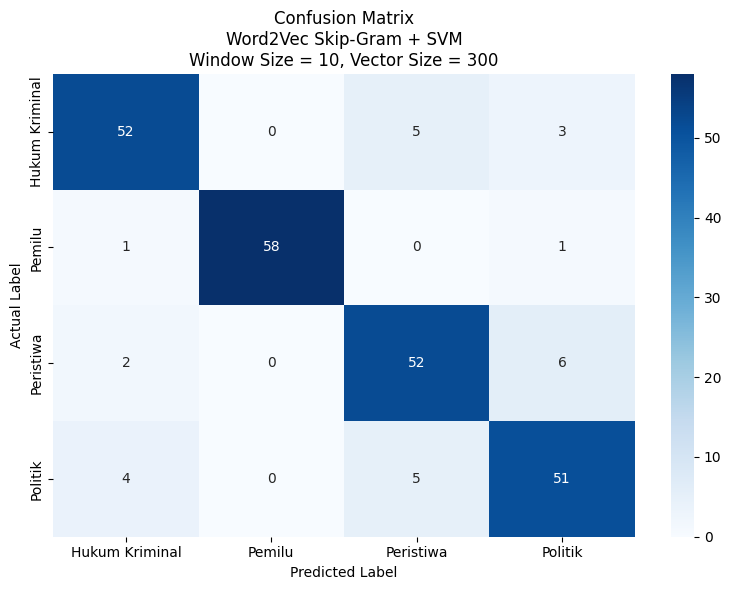

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.title(
    'Confusion Matrix\n'
    'Word2Vec Skip-Gram + SVM\n'
    'Window Size = 10, Vector Size = 300'
)

plt.tight_layout()
plt.show()

## Analisis Lanjutan 

In [16]:
import pandas as pd
import numpy as np

decision_scores = svm_model.decision_function(X_test)

error_analysis = []

for i in range(len(y_test)):

    if y_test[i] != y_pred[i]:

        idx = idx_test[i]

        words = df.loc[idx, 'Stemming']

        actual = label_encoder.inverse_transform([y_test[i]])[0]
        predicted = label_encoder.inverse_transform([y_pred[i]])[0]

        # confidence prediksi
        confidence = np.max(decision_scores[i])

        error_analysis.append({
            'Index': idx,
            'Actual': actual,
            'Predicted': predicted,
            'Jumlah_Kata': len(words),
            'Jumlah_Kata_Unik': len(set(words)),
            'Rasio_Kata_Unik': round(len(set(words))/len(words), 3),
            'Confidence': round(confidence, 3),
            'Preview_Text': ' '.join(words[:100]),
            'Perubahan_Kelas': f'{actual} -> {predicted}'
        })

error_df = pd.DataFrame(error_analysis)

print(error_df)

error_df.to_excel(
    'analisis_kesalahan.xlsx',
    index=False
)

    Index          Actual       Predicted  Jumlah_Kata  Jumlah_Kata_Unik  \
0      39         Politik       Peristiwa          176                95   
1     740       Peristiwa         Politik          157                93   
2      12         Politik  Hukum Kriminal          160                97   
3     132         Politik       Peristiwa          189               107   
4     552  Hukum Kriminal       Peristiwa          210               106   
5     388  Hukum Kriminal         Politik          167                95   
6     421  Hukum Kriminal       Peristiwa          192               115   
7     380  Hukum Kriminal       Peristiwa          232               130   
8      83         Politik  Hukum Kriminal          172               118   
9     460  Hukum Kriminal         Politik          190               101   
10    445  Hukum Kriminal         Politik          180               106   
11    138         Politik  Hukum Kriminal          195               103   
12   1069   

In [17]:
misclassified = []

for i, (actual, pred) in enumerate(zip(y_test, y_pred)):
    if actual != pred:
        idx = idx_test[i]

        misclassified.append({
            'Content': df.loc[idx, 'Content'],
            'Actual_Label': label_encoder.inverse_transform([actual])[0],
            'Predicted_Label': label_encoder.inverse_transform([pred])[0]
        })

misclassified_df = pd.DataFrame(misclassified)

print(misclassified_df.head())

                                             Content    Actual_Label  \
0  Wakil Presiden Gibran Rakabuming Raka mengungk...         Politik   
1  Menteri Kebudayaan (Menbud) Fadli Zon menegask...       Peristiwa   
2  Ketua Komisi III DPR RI Habiburokhman mengaku ...         Politik   
3  Anggota Komisi III DPR, Nasir Djamil mendesak ...         Politik   
4  Dua orang tewas dan tiga lainnya terluka dalam...  Hukum Kriminal   

  Predicted_Label  
0       Peristiwa  
1         Politik  
2  Hukum Kriminal  
3       Peristiwa  
4       Peristiwa  


In [18]:
misclassified_df.to_excel(
    'misclassified_news.xlsx',
    index=False
)

print("File berhasil disimpan: misclassified_news.xlsx")

File berhasil disimpan: misclassified_news.xlsx


### Confidence score

### Panjang Dokumen

## Analisis kosakata yang menyebabkan kesalahan